# Original MNIST experiments (executed, with outputs)

Executed notebook for the MNIST experiments reported in:

> I. A. Kistin, Sh. M. Isaev. *Diffusion Process Length and Inference Algorithm in
> Denoising-Diffusion Image Synthesis: A Controlled Empirical Study on MNIST and
> CIFAR-10.* The Visual Computer (submitted).

The cell outputs below are **preserved from the original run**, so the results can be
inspected without re-executing anything. This notebook produces:

| Output of this notebook | Where it appears in the paper |
|---|---|
| Training-loss curves for T = 100, 200, 400, 700, 1000 | **Fig. 1** |
| Sample grids for the five models | **Fig. 2** |
| DDPM sampling at 1000/500/200/100/50 restoration steps | **Fig. 5** |
| DDIM sampling at 50 restoration steps | **Fig. 6** |
| Intermediate states of the reverse process | **Fig. 8** |
| UMAP projections of the reverse trajectory | **Fig. 9** |
| Classifier-free guidance sweep (w = 1, 2, 3, 5, 7, 10) | **Fig. 10** |

---

## Important: scope of these results, and what supersedes them

These are the **original, single-seed** runs. They established the qualitative phenomena
reported in the paper, but they are **not** the source of the quantitative results in
Tables 1–3.

* **Tables 1–3 and Figs. 3, 4, 7** come from the later **seed-controlled re-runs**
  (`scripts/run_mnist_sweep.py`, `scripts/run_cifar_experiments.py`), which repeat every
  configuration over multiple random seeds and report FID as mean ± standard deviation.
* The FID-versus-T curve printed by Experiment 1 below is a **single-seed** measurement.
  It suggested a minimum at T = 200. The multi-seed re-runs did **not** confirm that
  ordering: at a 10-epoch budget the differences across T lie within seed-to-seed
  variability, and the reliable minimum only emerges at larger budgets, at T ≈ 700
  (see Table 1 of the paper). **The single-seed curve below is therefore superseded**,
  and it is kept here only for transparency: it is precisely the observation that
  motivated the seed-controlled protocol.
* The conditional model in the auxiliary experiment prints a *feature-space distance*
  computed with a lightweight random-projection proxy. It is **not** an Inception FID and
  is not comparable to the FID values in Tables 1–3; the paper reports that comparison
  qualitatively only.

Datasets: MNIST (public). Environment: single GPU. Random seeds and the full configuration
of the seed-controlled re-runs are given in `configs/` and Section 3.5 of the paper.

## Experiment 1 — Diffusion length under matched terminal noise (Figs. 1–2)

Five unconditional DDPM models are trained on MNIST with T = 100, 200, 400, 700 and 1000
diffusion steps. For every T the noise schedule is tuned so that the **cumulative signal
retention at the final step is identical** (ᾱ_T ≈ 10⁻³, with β₁ fixed): a longer chain
therefore does not inject more total noise, and the number of steps is the only variable.
Sampling uses DDPM with the same number of steps as in training.

Outputs: the training-loss curves (**Fig. 1**), the sample grids (**Fig. 2**), and the
single-seed FID-versus-T curve (superseded — see the note above).

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.94MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.4MB/s]
100%|██████████| 10/10 [01:51<00:00, 11.14s/it]


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth



  0%|          | 0.00/104M [00:00<?, ?B/s]
 18%|█▊        | 18.5M/104M [00:00<00:00, 193MB/s]
 36%|███▌      | 37.0M/104M [00:00<00:00, 193MB/s]
 53%|█████▎    | 55.5M/104M [00:00<00:00, 185MB/s]
 71%|███████   | 73.5M/104M [00:00<00:00, 186MB/s]
100%|██████████| 104M/104M [00:00<00:00, 189MB/s] 
100%|██████████| 5/5 [00:00<00:00, 227.55it/s]


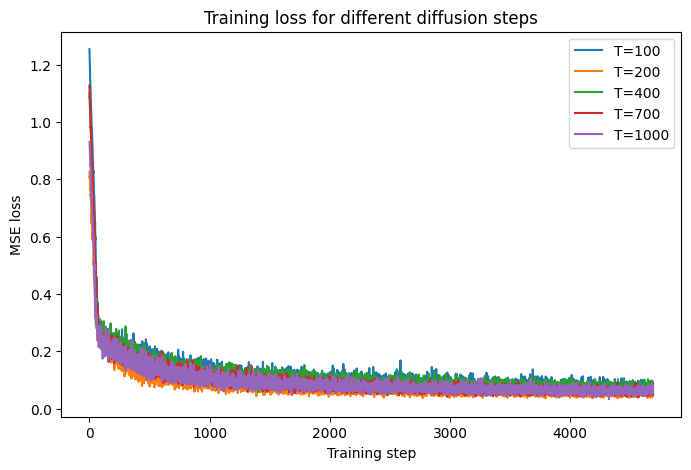

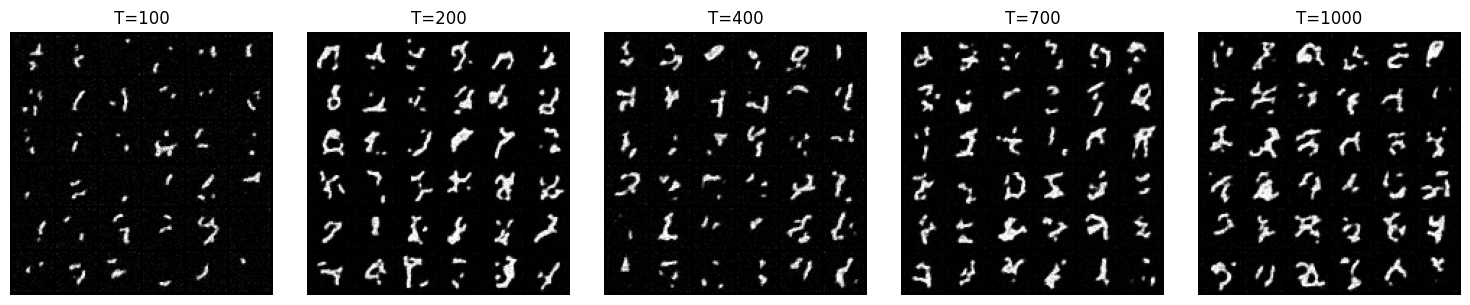

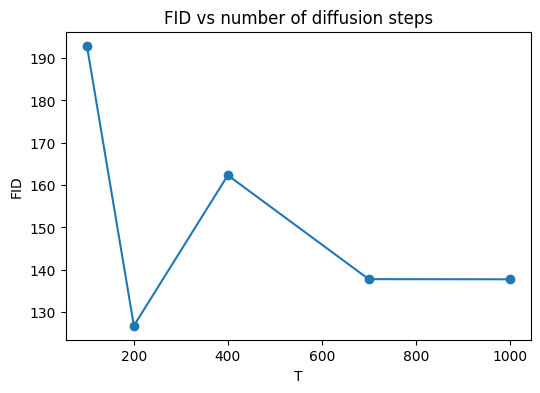

In [ ]:
import math, os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2. - 1.)
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

def sinusoidal_embedding(timesteps, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=timesteps.device) / half)
    args = timesteps.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=1)
    return emb

class SimpleUNet(nn.Module):
    def __init__(self, time_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )
        self.conv0 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv1 = nn.Conv2d(32, 64, 4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 4, stride=2, padding=1)
        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.deconv1 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1)
        self.out_conv = nn.Conv2d(32, 1, 3, padding=1)
        self.act = nn.SiLU()
        self.time_dim = time_dim

    def forward(self, x, t):
        t = sinusoidal_embedding(t, self.time_dim)
        t = self.time_mlp(t)
        t = t[:, :, None, None]
        h0 = self.act(self.conv0(x))
        h1 = self.act(self.conv1(h0))
        h2 = self.act(self.conv2(h1))
        h3 = self.act(self.conv3(h2 + t)
)
        u1 = self.act(self.deconv1(h3)) + h1
        u2 = self.act(self.deconv2(u1)) + h0
        out = self.out_conv(u2)
        return out

def make_schedule(T, beta_1=1e-4, target_alpha_bar_T=1e-3):
    low, high = beta_1, 0.999
    for _ in range(100):
        mid = (low + high) / 2
        betas = torch.linspace(beta_1, mid, T)
        alphas = 1. - betas
        alpha_bar = torch.cumprod(alphas, dim=0)
        if alpha_bar[-1] > target_alpha_bar_T:
            low = mid
        else:
            high = mid
    betas = torch.linspace(beta_1, high, T, device=device)
    alphas = 1. - betas
    alpha_bar = torch.cumprod(alphas, dim=0)
    sqrt_alpha_bar = torch.sqrt(alpha_bar)
    sqrt_one_minus_alpha_bar = torch.sqrt(1. - alpha_bar)
    return {
        'T': T,
        'betas': betas,
        'alphas': alphas,
        'alpha_bar': alpha_bar,
        'sqrt_alpha_bar': sqrt_alpha_bar,
        'sqrt_one_minus_alpha_bar': sqrt_one_minus_alpha_bar
    }

def train_ddpm(T, epochs):
    schedule = make_schedule(T)
    model = SimpleUNet().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=2e-4)
    loss_history = []
    for epoch in tqdm(range(epochs)):
        for x, _ in train_loader:
            x = x.to(device)
            t = torch.randint(0, T, (x.size(0),), device=device)
            noise = torch.randn_like(x)
            sqrt_ab = schedule['sqrt_alpha_bar'][t].view(-1, 1, 1, 1)
            sqrt_omb = schedule['sqrt_one_minus_alpha_bar'][t].view(-1, 1, 1, 1)
            x_t = sqrt_ab * x + sqrt_omb * noise
            pred_noise = model(x_t, t)
            loss = torch.mean((noise - pred_noise) ** 2)
            opt.zero_grad()
            loss.backward()
            opt.step()
            loss_history.append(loss.item())
    return model, schedule, loss_history

def sample_ddpm(model, schedule, n_samples, steps=None):
    model.eval()
    T = schedule['T']
    if steps is None:
        steps = list(range(T - 1, -1, -1))
    x = torch.randn(n_samples, 1, 28, 28, device=device)
    with torch.no_grad():
        for i in steps:
            t = torch.full((n_samples,), i, device=device, dtype=torch.long)
            eps = model(x, t)
            alpha = schedule['alphas'][i]
            alpha_bar = schedule['alpha_bar'][i]
            beta = schedule['betas'][i]
            x = (1. / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1. - alpha_bar)) * eps)
            if i > 0:
                z = torch.randn_like(x)
                x = x + torch.sqrt(beta) * z
    x = x.clamp(-1., 1.)
    return x

def get_inception():
    import torchvision.models as tv_models
    try:
        inception = tv_models.inception_v3(weights=tv_models.Inception_V3_Weights.IMAGENET1K_V1, transform_input=False)
    except:
        inception = tv_models.inception_v3(pretrained=True, transform_input=False)
    inception.fc = nn.Identity()
    inception.eval()
    inception.to(device)
    return inception

def prepare_inception_input(imgs):
    imgs = (imgs + 1.) / 2.
    imgs = torch.nn.functional.interpolate(imgs, size=(299, 299), mode='bilinear', align_corners=False)
    mean = torch.tensor([0.485, 0.456, 0.406], device=imgs.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=imgs.device).view(1, 3, 1, 1)
    imgs = imgs.repeat(1, 3, 1, 1)
    imgs = (imgs - mean) / std
    return imgs

def get_activations(inception, loader_or_tensor, max_samples):
    feats = []
    with torch.no_grad():
        if isinstance(loader_or_tensor, DataLoader):
            seen = 0
            for x, _ in loader_or_tensor:
                x = x.to(device)
                x = prepare_inception_input(x)
                f = inception(x)
                feats.append(f.cpu().numpy())
                seen += f.size(0)
                if seen >= max_samples:
                    break
        else:
            data = loader_or_tensor
            seen = 0
            while seen < max_samples:
                cur = min(128, max_samples - seen)
                x = data(cur).to(device)
                x = prepare_inception_input(x)
                f = inception(x)
                feats.append(f.cpu().numpy())
                seen += cur
    feats = np.concatenate(feats, axis=0)[:max_samples]
    return feats

def compute_fid(mu1, sigma1, mu2, sigma2):
    diff = mu1 - mu2
    covmean = sigma1.dot(sigma2)
    eigvals = np.linalg.eigvals(covmean)
    eigvals = np.real(eigvals)
    eigvals[eigvals < 0] = 0
    tr_covmean = np.sum(np.sqrt(eigvals))
    fid = diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * tr_covmean
    return float(fid)

def compute_fid_for_model(model, schedule, n_real=5000, n_gen=5000):
    inception = get_inception()
    real_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    real_feats = get_activations(inception, real_loader, n_real)
    mu_real = np.mean(real_feats, axis=0)
    sigma_real = np.cov(real_feats, rowvar=False)
    def gen_fn(batch_size):
        return sample_ddpm(model, schedule, batch_size)
    gen_feats = get_activations(inception, gen_fn, n_gen)
    mu_gen = np.mean(gen_feats, axis=0)
    sigma_gen = np.cov(gen_feats, rowvar=False)
    return compute_fid(mu_real, sigma_real, mu_gen, sigma_gen)

Ts = [100, 200, 400, 700, 1000]
epochs = 10
models = {}
schedules = {}
losses = {}
fid_scores = {}

for T in tqdm(Ts):
    model, schedule, loss_hist = train_ddpm(T, epochs)
    models[T] = model
    schedules[T] = schedule
    losses[T] = loss_hist
    fid_scores[T] = compute_fid_for_model(model, schedule, n_real=3000, n_gen=3000)

plt.figure(figsize=(8, 5))
for T in tqdm(Ts):
    plt.plot(losses[T], label=f"T={T}")
plt.xlabel("Training step")
plt.ylabel("MSE loss")
plt.legend()
plt.title("Training loss for different diffusion steps")
plt.show()

fig, axes = plt.subplots(1, len(Ts), figsize=(3 * len(Ts), 3))
for idx, T in enumerate(Ts):
    samples = sample_ddpm(models[T], schedules[T], 36)
    grid = make_grid((samples.cpu() + 1) / 2, nrow=6)
    axes[idx].imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    axes[idx].axis('off')
    axes[idx].set_title(f"T={T}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(Ts, [fid_scores[T] for T in Ts], marker='o')
plt.xlabel("T")
plt.ylabel("FID")
plt.title("FID vs number of diffusion steps")
plt.show()

**Reading the third plot.** The FID-versus-T curve above is the single-seed measurement
discussed in the header: it places the minimum at T = 200. The seed-controlled re-run
(Table 1, Fig. 3 of the paper) shows that at this training budget the differences across T
are within seed-to-seed variability, and that a reliable minimum at T ≈ 700 only appears at
larger budgets. The curve is retained here as the original evidence that prompted the
multi-seed protocol.

## Experiment 2 — Reduced-step sampling: DDPM vs DDIM (Figs. 5–6)

For the model trained with T = 1000, the reverse process is run with fewer restoration
steps than it was trained on: DDPM at 1000, 500, 200, 100 and 50 steps, and the
deterministic DDIM sampler at 50 steps. Both samplers traverse the **same** uniformly
spaced subset of the training index grid, so the comparison isolates the sampler.

Outputs: DDPM degradation across step budgets (**Fig. 5**) and DDIM at 50 steps (**Fig. 6**).
The quantitative version of this comparison, on CIFAR-10 with FID at every step budget, is
Table 3 / Fig. 7 of the paper.

4it [00:01,  3.16it/s]


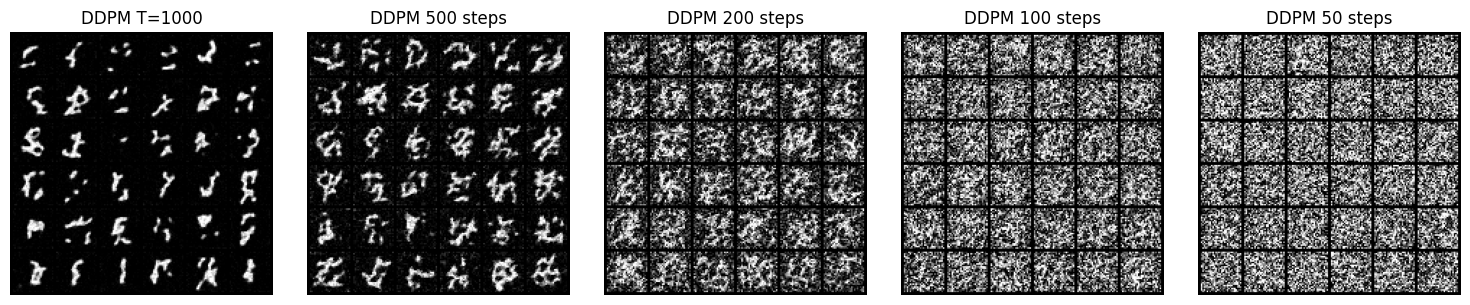

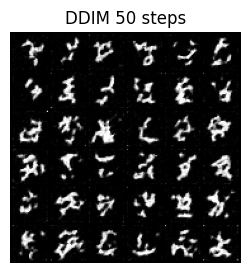

In [ ]:
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

base_T = 1000
base_model = models[base_T]
base_schedule = schedules[base_T]

def make_steps(T_train, T_infer):
    idxs = torch.linspace(0, T_train - 1, T_infer, dtype=torch.long)
    return list(reversed(idxs.tolist()))

def sample_ddim(model, schedule, n_samples, steps):
    model.eval()
    alpha_bar = schedule['alpha_bar']
    x = torch.randn(n_samples, 1, 28, 28, device=device)
    with torch.no_grad():
        for i, j in zip(steps[:-1], steps[1:]):
            t = torch.full((n_samples,), i, device=device, dtype=torch.long)
            eps = model(x, t)
            a_i = alpha_bar[i]
            a_j = alpha_bar[j]
            x0 = (x - torch.sqrt(1. - a_i) * eps) / torch.sqrt(a_i)
            x = torch.sqrt(a_j) * x0 + torch.sqrt(1. - a_j) * eps
    x = x.clamp(-1., 1.)
    return x

infer_steps = [500, 200, 100, 50]
fig, axes = plt.subplots(1, len(infer_steps) + 1, figsize=(3 * (len(infer_steps) + 1), 3))

samples_full = sample_ddpm(base_model, base_schedule, 36)
grid_full = make_grid((samples_full.cpu() + 1) / 2, nrow=6)
axes[0].imshow(np.transpose(grid_full.numpy(), (1, 2, 0)))
axes[0].axis('off')
axes[0].set_title("DDPM T=1000")

for idx, s in tqdm(enumerate(infer_steps)):
    steps = make_steps(base_T, s)
    samples = sample_ddpm(base_model, base_schedule, 36, steps=steps)
    grid = make_grid((samples.cpu() + 1) / 2, nrow=6)
    axes[idx + 1].imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    axes[idx + 1].axis('off')
    axes[idx + 1].set_title(f"DDPM {s} steps")

plt.tight_layout()
plt.show()

steps_ddim = make_steps(base_T, 50)
samples_ddim = sample_ddim(base_model, base_schedule, 36, steps_ddim)
grid_ddim = make_grid((samples_ddim.cpu() + 1) / 2, nrow=6)
plt.figure(figsize=(3, 3))
plt.imshow(np.transpose(grid_ddim.numpy(), (1, 2, 0)))
plt.axis('off')
plt.title("DDIM 50 steps")
plt.show()

## Experiment 3 — Intermediate states of the reverse process (Fig. 8)

Five evenly spaced intermediate states of the reverse trajectory are fixed, and sampling is
then continued independently from each of them to completion. This shows how structure
emerges from noise, and that a single intermediate state can lead to different final digits
along different stochastic trajectories.

100%|██████████| 200/200 [00:00<00:00, 785.92it/s]


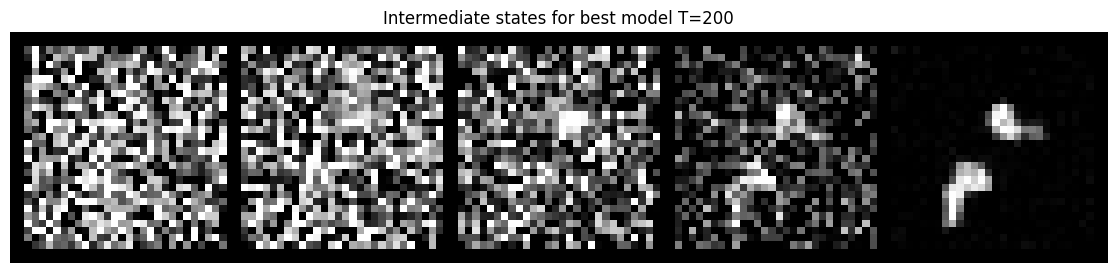

100%|██████████| 5/5 [00:00<00:00,  6.40it/s]


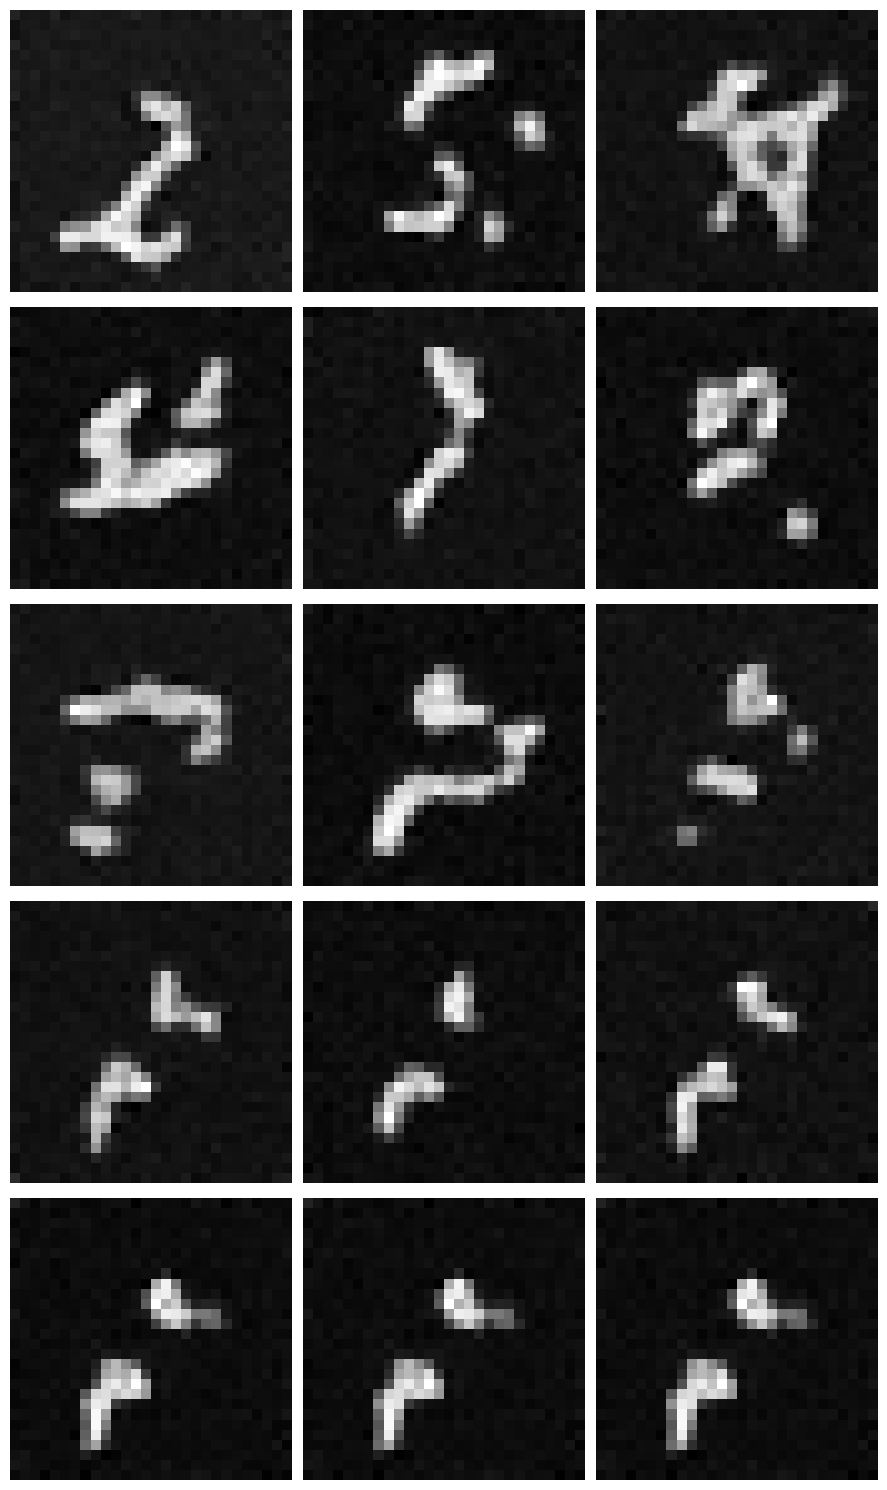

In [ ]:
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

best_T = min(fid_scores, key=lambda k: fid_scores[k])
best_model = models[best_T]
best_schedule = schedules[best_T]

T = best_schedule['T']
save_ts = torch.linspace(T - 1, 0, steps=5, dtype=torch.long)
save_ts = sorted(save_ts.tolist(), reverse=True)

x = torch.randn(1, 1, 28, 28, device=device)
states = {}

with torch.no_grad():
    for i in tqdm(range(T - 1, -1, -1)):
        t = torch.full((1,), i, device=device, dtype=torch.long)
        eps = best_model(x, t)
        alpha = best_schedule['alphas'][i]
        alpha_bar = best_schedule['alpha_bar'][i]
        beta = best_schedule['betas'][i]
        x = (1. / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1. - alpha_bar)) * eps)
        if i > 0:
            z = torch.randn_like(x)
            x = x + torch.sqrt(beta) * z
        if i in save_ts and i not in states:
            states[i] = x.clone()

ordered_ts = sorted(states.keys(), reverse=True)
noisy_images = torch.cat([states[t] for t in ordered_ts], dim=0)
grid_noisy = make_grid((noisy_images.cpu() + 1) / 2, nrow=len(ordered_ts))
plt.figure(figsize=(3 * len(ordered_ts), 3))
plt.imshow(np.transpose(grid_noisy.numpy(), (1, 2, 0)))
plt.axis('off')
plt.title(f"Intermediate states for best model T={best_T}")
plt.show()

all_samples = []
for t in tqdm(ordered_ts):
    start = states[t].repeat(3, 1, 1, 1)
    x_branch = start.clone()
    with torch.no_grad():
        for i in range(t, -1, -1):
            tt = torch.full((x_branch.size(0),), i, device=device, dtype=torch.long)
            eps = best_model(x_branch, tt)
            alpha = best_schedule['alphas'][i]
            alpha_bar = best_schedule['alpha_bar'][i]
            beta = best_schedule['betas'][i]
            x_branch = (1. / torch.sqrt(alpha)) * (x_branch - (beta / torch.sqrt(1. - alpha_bar)) * eps)
            if i > 0:
                z = torch.randn_like(x_branch)
                x_branch = x_branch + torch.sqrt(beta) * z
    all_samples.append(x_branch.cpu())

all_samples = torch.stack(all_samples, dim=0)
rows = all_samples.size(0)
cols = all_samples.size(1)
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
for i in range(rows):
    for j in range(cols):
        img = (all_samples[i, j] + 1) / 2
        img = img.squeeze(0)
        axes[i, j].imshow(img.numpy(), cmap='gray')
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()

---

# Auxiliary experiments (Section 7 of the paper)

The experiments below are **auxiliary**: they reproduce known conditioning behaviour and are
not part of the controlled step-count comparison that is the subject of the paper.

## Conditional diffusion model

A **separate** network is used here: a diffusers `UNet2DConditionModel` in which a learned
label embedding is injected through cross-attention, trained with the **standard linear DDPM
schedule** (β from 10⁻⁴ to 2·10⁻², T = 1000) — *not* the matched-noise schedule of
Experiments 1–3.

The score printed below is a **random-projection feature-space proxy**, not an Inception FID;
it is not comparable to the FID values in Tables 1–3 and the paper uses it only as a
qualitative, within-experiment comparison against the unconditional model.

In [ ]:
!pip -q install diffusers umap-learn

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import torchvision
from diffusers import UNet2DConditionModel, DDPMScheduler

device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 128

transform = transforms.ToTensor()
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)

class CondUNet(nn.Module):
    def __init__(self, num_classes, cond_dim=128):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, cond_dim)
        self.unet = UNet2DConditionModel(
            sample_size=28,
            in_channels=1,
            out_channels=1,
            layers_per_block=2,
            block_out_channels=(64, 128, 256),
            down_block_types=("DownBlock2D", "DownBlock2D", "DownBlock2D"),
            up_block_types=("UpBlock2D", "UpBlock2D", "UpBlock2D"),
            cross_attention_dim=cond_dim,
        )

    def forward(self, x, t, y):
        emb = self.label_emb(y).unsqueeze(1)
        return self.unet(x, t, encoder_hidden_states=emb).sample

model = CondUNet(num_classes=10).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = DDPMScheduler(num_train_timesteps=1000, beta_start=1e-4, beta_end=0.02)

epochs = 5
model.train()
for epoch in tqdm(range(epochs)):
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        x = x * 2 - 1
        b = x.size(0)
        t = torch.randint(0, scheduler.num_train_timesteps, (b,), device=device).long()
        noise = torch.randn_like(x)
        x_noisy = scheduler.add_noise(x, noise, t)
        pred = model(x_noisy, t, y)
        loss = F.mse_loss(pred, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"epoch {epoch+1}: {loss.item():.4f}")

@torch.no_grad()
def sample(model, scheduler, labels, num_steps=50):
    model.eval()
    n = labels.size(0)
    x = torch.randn(n, 1, 28, 28, device=device)
    scheduler.set_timesteps(num_steps)
    for t in scheduler.timesteps:
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)
        eps = model(x, t_batch, labels)
        x = scheduler.step(eps, t, x).prev_sample
    x = (x + 1) / 2
    x = x.clamp(0, 1)
    return x

proj = nn.Linear(28 * 28, 64, bias=False).to(device)
for p in proj.parameters():
    p.requires_grad = False

def get_feats(images):
    x = images.view(images.size(0), -1).to(device)
    return proj(x).detach()

def compute_stats_real(n_samples=2000):
    feats = []
    total = 0
    for x, _ in test_loader:
        feats.append(get_feats(x))
        total += x.size(0)
        if total >= n_samples:
            break
    feats = torch.cat(feats, dim=0)[:n_samples]
    mu = feats.mean(0)
    xc = feats - mu
    cov = xc.T @ xc / (xc.size(0) - 1)
    return mu, cov

def compute_stats_fake(n_samples=2000, num_steps=50):
    feats = []
    total = 0
    while total < n_samples:
        bs = min(256, n_samples - total)
        labels = torch.randint(0, 10, (bs,), device=device)
        imgs = sample(model, scheduler, labels, num_steps=num_steps).cpu()
        feats.append(get_feats(imgs))
        total += bs
    feats = torch.cat(feats, dim=0)[:n_samples]
    mu = feats.mean(0)
    xc = feats - mu
    cov = xc.T @ xc / (xc.size(0) - 1)
    return mu, cov

def fid_from_stats(mu1, cov1, mu2, cov2):
    diff = mu1 - mu2
    cov_prod = cov1 @ cov2
    eigvals = torch.linalg.eigvals(cov_prod)
    eigvals = eigvals.real.clamp(min=0)
    trace_sqrt = eigvals.sqrt().sum()
    fid = diff.dot(diff) + torch.trace(cov1) + torch.trace(cov2) - 2 * trace_sqrt
    return fid.item()

mu_real, cov_real = compute_stats_real(n_samples=2000)
mu_fake, cov_fake = compute_stats_fake(n_samples=2000, num_steps=50)
fid_score = fid_from_stats(mu_real, cov_real, mu_fake, cov_fake)
print("Conditional diffusion FID-like score:", fid_score)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
  0%|          | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
 20%|██        | 1/5 [02:30<10:00, 150.22s/it]

epoch 1: 0.0338


 40%|████      | 2/5 [04:58<07:27, 149.29s/it]

epoch 2: 0.0325


 60%|██████    | 3/5 [07:27<04:58, 149.12s/it]

...

 80%|████████  | 4/5 [09:56<02:28, 148.99s/it]

epoch 4: 0.0258


100%|██████████| 5/5 [12:25<00:00, 149.01s/it]

epoch 5: 0.0233


Conditional diffusion FID-like score: 0.08703470230102539


## UMAP projections of the reverse trajectory (Fig. 9)

Samples are drawn for all ten classes at five evenly spaced points of the reverse process and
projected to two dimensions with UMAP, one colour per digit class.

100%|██████████| 100/100 [00:56<00:00,  1.76it/s]


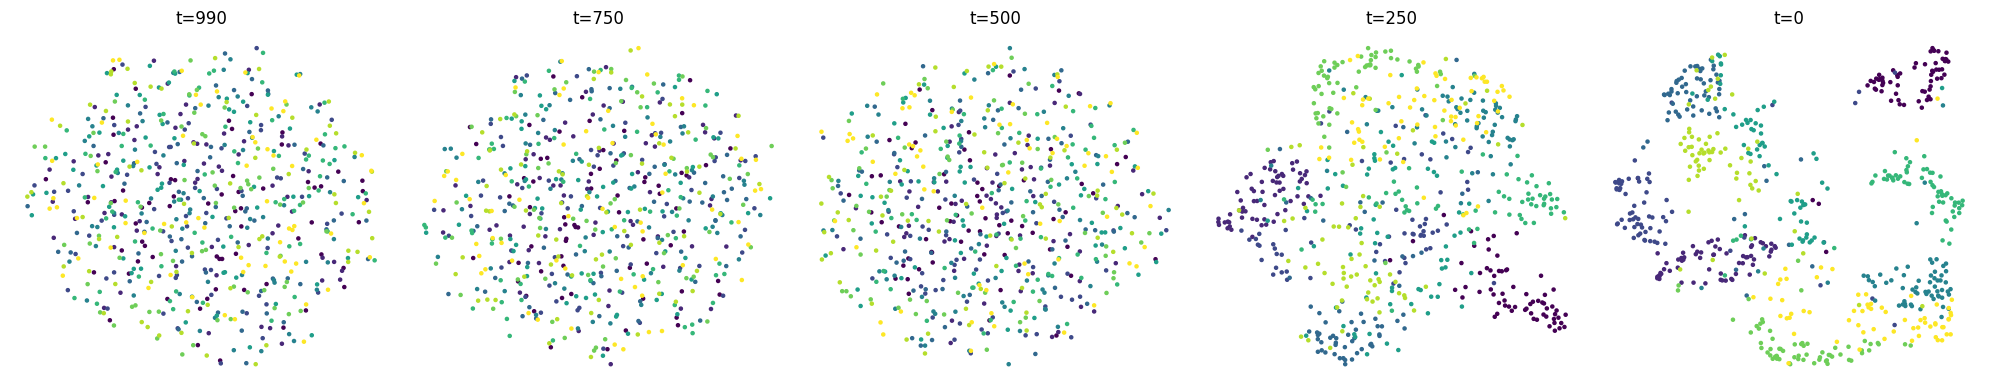

In [ ]:
import umap
import matplotlib.pyplot as plt

num_per_class = 64
labels = torch.arange(10, device=device).repeat_interleave(num_per_class)
x = torch.randn(labels.size(0), 1, 28, 28, device=device)

scheduler.set_timesteps(100)
timesteps = scheduler.timesteps
idxs = torch.linspace(0, len(timesteps) - 1, 5, dtype=torch.long)
chosen = [timesteps[i].item() for i in idxs]
states = {t: None for t in chosen}

model.eval()
with torch.no_grad():
    for t in tqdm(timesteps):
        t_batch = torch.full((labels.size(0),), t, device=device, dtype=torch.long)
        eps = model(x, t_batch, labels)
        x = scheduler.step(eps, t, x).prev_sample
        t_int = t.item()
        if t_int in states and states[t_int] is None:
            states[t_int] = x.detach().cpu()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (t, val) in zip(axes, states.items()):
    imgs = (val + 1) / 2
    imgs = imgs.view(imgs.size(0), -1)
    reducer = umap.UMAP(n_components=2)
    emb = reducer.fit_transform(imgs.numpy())
    ax.scatter(emb[:, 0], emb[:, 1], c=labels.cpu().numpy(), s=5)
    ax.set_title(f"t={t}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Classifier-free guidance (Fig. 10)

The conditional model is fine-tuned with the label replaced by an empty class in 20% of
training cases, and sampled with guidance weights w = 1, 2, 3, 5, 7 and 10.

  0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
 33%|███▎      | 1/3 [02:30<05:00, 150.14s/it]

cfg epoch 1: 0.0226


 67%|██████▋   | 2/3 [04:59<02:29, 149.59s/it]

cfg epoch 2: 0.0246


100%|██████████| 3/3 [07:28<00:00, 149.34s/it]

cfg epoch 3: 0.0203


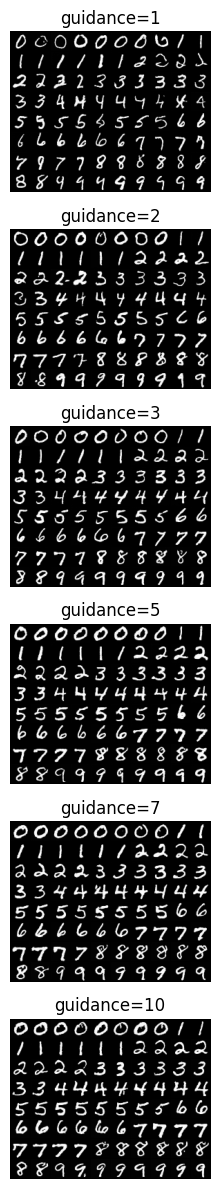

In [ ]:
import matplotlib.pyplot as plt

cfg_model = CondUNet(num_classes=11).to(device)
state = model.state_dict()
new_state = cfg_model.state_dict()
for k in new_state:
    if k in state and state[k].shape == new_state[k].shape:
        new_state[k] = state[k]
cfg_model.load_state_dict(new_state)

optimizer_cfg = torch.optim.AdamW(cfg_model.parameters(), lr=5e-5)
p_uncond = 0.2
epochs_cfg = 3

cfg_model.train()
for epoch in tqdm(range(epochs_cfg)):
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        x = x * 2 - 1
        b = x.size(0)
        t = torch.randint(0, scheduler.num_train_timesteps, (b,), device=device).long()
        y_cf = y.clone()
        uncond_mask = torch.rand(b, device=device) < p_uncond
        y_cf[uncond_mask] = 10
        noise = torch.randn_like(x)
        x_noisy = scheduler.add_noise(x, noise, t)
        pred = cfg_model(x_noisy, t, y_cf)
        loss = F.mse_loss(pred, noise)
        optimizer_cfg.zero_grad()
        loss.backward()
        optimizer_cfg.step()
    print(f"cfg epoch {epoch+1}: {loss.item():.4f}")

@torch.no_grad()
def sample_cfg(model, scheduler, labels, guidance_scale, num_steps=50):
    model.eval()
    n = labels.size(0)
    x = torch.randn(n, 1, 28, 28, device=device)
    scheduler.set_timesteps(num_steps)
    uncond_labels = torch.full_like(labels, 10)
    for t in scheduler.timesteps:
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)
        eps_cond = model(x, t_batch, labels)
        eps_uncond = model(x, t_batch, uncond_labels)
        eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)
        x = scheduler.step(eps, t, x).prev_sample
    x = (x + 1) / 2
    x = x.clamp(0, 1)
    return x

guidance_scales = [1, 2, 3, 5, 7, 10]
labels_grid = torch.arange(10, device=device).repeat_interleave(8)

fig, axes = plt.subplots(len(guidance_scales), 1, figsize=(8, 12))
for ax, gs in zip(axes, guidance_scales):
    imgs = sample_cfg(cfg_model, scheduler, labels_grid, gs, num_steps=50)
    imgs = imgs.cpu()
    grid = torchvision.utils.make_grid(imgs, nrow=10, padding=1)
    ax.imshow(grid.permute(1, 2, 0), cmap="gray")
    ax.set_title(f"guidance={gs}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Observations

1. **Diffusion length.** Under a matched terminal signal and a fixed training budget,
   generation quality does not improve monotonically with T. The single-seed curve above
   suggested an intermediate optimum; the seed-controlled re-runs (Table 1 of the paper)
   confirm that the dependence is non-monotonic and budget-dependent, with the reliable
   minimum at T ≈ 700 rather than at the longest process, and with the 10-epoch differences
   lying within seed-to-seed variability.

2. **Sampler at a reduced step budget.** Stochastic DDPM sampling degrades sharply when steps
   are removed from a model trained on a long chain, dissolving into noise at 100 and 50
   steps, whereas the deterministic DDIM sampler keeps the digits recognisable at 50 steps.
   On CIFAR-10 this gap is quantified as a five-fold difference in FID (Table 3 of the paper).

3. **Reverse trajectory.** Class structure appears only late in the reverse process: the UMAP
   projections show all classes overlapping at t = 990 and separating into one cluster per
   digit as t → 0.

4. **Classifier-free guidance.** Larger guidance weights sharpen the samples and improve class
   adherence, at the cost of diversity — the fidelity-versus-diversity trade-off expected for
   guided diffusion models.